## **Тема:**
### StyleGAN2


## **Цель:**  
### Создать систему, которая позволяет редактировать лица на изображениях с помощью текстовых описаний

## **Инструменты:**
### Две готовые нейросети:
### - **StyleGAN2** (генерирует фотореалистичные лица)
### - **CLIP** (понимает связь между текстом и изображениями).

---

***!!! В данной работе мы не будем обучать модели с нуля, а планируем использовать предобученные SOTA-модели и написать "клей" между ними.***




## Подготовка

In [2]:
!pip install git+https://github.com/openai/CLIP.git

  Cloning https://github.com/openai/CLIP.git to /tmp/pip-req-build-uhc_6dg0
  Running command git clone --filter=blob:none --quiet https://github.com/openai/CLIP.git /tmp/pip-req-build-uhc_6dg0
  Resolved https://github.com/openai/CLIP.git to commit dcba3cb2e2827b402d2701e7e1c7d9fed8a20ef1
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 3.4 MB/s eta 0:00:00
  Created wheel for clip: filename=clip-1.0-py3-none-any.whl size=1369490 sha256=dc7dfcb0170f21563ea6fcdf0f0e784659ec2a789034e9a3c7f9c4d7b6724b89
  Stored in directory: /tmp/pip-ephem-wheel-cache-yah8_iw2/wheels/35/3e/df/3d24cbfb3b6a06f17a2bfd7d1138900d4365d9028aa8f6e92f
Successfully built clip


In [3]:
!pip install ninja
!git clone https://github.com/NVlabs/stylegan2-ada-pytorch.git
%cd stylegan2-ada-pytorch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.7/180.7 kB 8.6 MB/s eta 0:00:00
Cloning into 'stylegan2-ada-pytorch'...
remote: Enumerating objects: 131, done.
remote: Counting objects: 100% (2/2), done.
remote: Compressing objects: 100% (2/2), done.
remote: Total 131 (delta 0), reused 0 (delta 0), pack-reused 129 (from 2)
Receiving objects: 100% (131/131), 1.13 MiB | 3.62 MiB/s, done.
Resolving deltas: 100% (57/57), done.
/content/stylegan2-ada-pytorch


In [17]:
# Импортируем библиотеки
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim


import clip
import numpy as np
import matplotlib.pyplot as plt
import requests
import os
import sys
import time
import warnings
import io
import ipywidgets as widgets
import dnnlib
import legacy

from torchvision import transforms, utils
from PIL import Image, ImageDraw, ImageFont
from IPython.display import display, clear_output
from io import BytesIO
from google.colab import files
from google.colab import output

warnings.filterwarnings('ignore', message='.*plugin.*')

In [16]:
# Проверяем доступность GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


In [6]:
# Скачиваем предобученные веса StyleGAN2 для лиц (FFHQ, 512x512)
!wget -O stylegan2-ffhq-config-f.pt https://nvlabs-fi-cdn.nvidia.com/stylegan2-ada-pytorch/pretrained/ffhq.pkl

# !gdown --id 1EM87UquaoQmk17Q8d5kYIAHqu0dkYqdT -O stylegan2-ffhq-config-f.pt

--2025-12-18 03:31:45--  https://nvlabs-fi-cdn.nvidia.com/stylegan2-ada-pytorch/pretrained/ffhq.pkl
Resolving nvlabs-fi-cdn.nvidia.com (nvlabs-fi-cdn.nvidia.com)... 99.84.215.96, 99.84.215.98, 99.84.215.15, ...
Connecting to nvlabs-fi-cdn.nvidia.com (nvlabs-fi-cdn.nvidia.com)|99.84.215.96|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 381624121 (364M) [binary/octet-stream]
Saving to: ‘stylegan2-ffhq-config-f.pt’

stylegan2-ffhq-conf 100%[===================>] 363.94M  18.6MB/s    in 22s     

2025-12-18 03:32:07 (16.7 MB/s) - ‘stylegan2-ffhq-config-f.pt’ saved [381624121/381624121]



In [7]:
# Загружаем CLIP
clip_model, preprocess = clip.load("ViT-B/32", device=device)
clip_model.eval()

100%|███████████████████████████████████████| 338M/338M [00:10<00:00, 34.7MiB/s]


CLIP(
  (visual): VisionTransformer(
    (conv1): Conv2d(3, 768, kernel_size=(32, 32), stride=(32, 32), bias=False)
    (ln_pre): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
    (transformer): Transformer(
      (resblocks): Sequential(
        (0): ResidualAttentionBlock(
          (attn): MultiheadAttention(
            (out_proj): NonDynamicallyQuantizableLinear(in_features=768, out_features=768, bias=True)
          )
          (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
          (mlp): Sequential(
            (c_fc): Linear(in_features=768, out_features=3072, bias=True)
            (gelu): QuickGELU()
            (c_proj): Linear(in_features=3072, out_features=768, bias=True)
          )
          (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        )
        (1): ResidualAttentionBlock(
          (attn): MultiheadAttention(
            (out_proj): NonDynamicallyQuantizableLinear(in_features=768, out_features=768, bias=True)
          

In [11]:
!wget -O /content/stylegan2-ffhq-config-f.pt https://nvlabs-fi-cdn.nvidia.com/stylegan2-ada-pytorch/pretrained/ffhq.pkl

--2025-12-18 03:34:41--  https://nvlabs-fi-cdn.nvidia.com/stylegan2-ada-pytorch/pretrained/ffhq.pkl
Resolving nvlabs-fi-cdn.nvidia.com (nvlabs-fi-cdn.nvidia.com)... 99.84.215.15, 99.84.215.96, 99.84.215.98, ...
Connecting to nvlabs-fi-cdn.nvidia.com (nvlabs-fi-cdn.nvidia.com)|99.84.215.15|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 381624121 (364M) [binary/octet-stream]
Saving to: ‘/content/stylegan2-ffhq-config-f.pt’

/content/stylegan2- 100%[===================>] 363.94M  22.6MB/s    in 18s     

2025-12-18 03:35:00 (20.3 MB/s) - ‘/content/stylegan2-ffhq-config-f.pt’ saved [381624121/381624121]



In [14]:
# Загружаем StyleGAN2
sys.path.insert(0, '/content')

with dnnlib.util.open_url('/content/stylegan2-ffhq-config-f.pt') as f:
    gan = legacy.load_network_pkl(f)['G_ema'].to(device)

gan.eval()

print(f"Архитектура: {gan}")

Архитектура: Generator(
  (synthesis): SynthesisNetwork(
    (b4): SynthesisBlock(
      (conv1): SynthesisLayer(
        (affine): FullyConnectedLayer()
      )
      (torgb): ToRGBLayer(
        (affine): FullyConnectedLayer()
      )
    )
    (b8): SynthesisBlock(
      (conv0): SynthesisLayer(
        (affine): FullyConnectedLayer()
      )
      (conv1): SynthesisLayer(
        (affine): FullyConnectedLayer()
      )
      (torgb): ToRGBLayer(
        (affine): FullyConnectedLayer()
      )
    )
    (b16): SynthesisBlock(
      (conv0): SynthesisLayer(
        (affine): FullyConnectedLayer()
      )
      (conv1): SynthesisLayer(
        (affine): FullyConnectedLayer()
      )
      (torgb): ToRGBLayer(
        (affine): FullyConnectedLayer()
      )
    )
    (b32): SynthesisBlock(
      (conv0): SynthesisLayer(
        (affine): FullyConnectedLayer()
      )
      (conv1): SynthesisLayer(
        (affine): FullyConnectedLayer()
      )
      (torgb): ToRGBLayer(
        (affin

## Генерация

Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!


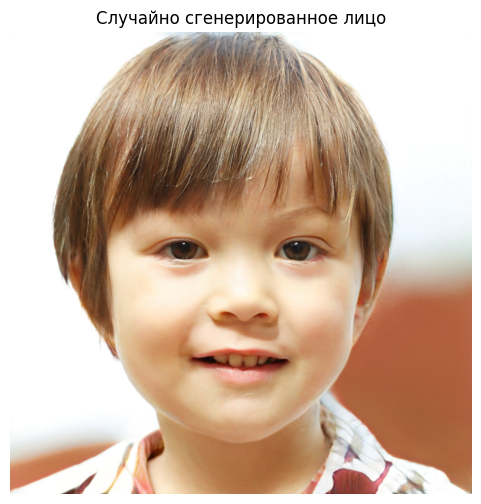

In [22]:
# Создадим функции для генерации и отображения изображений
def generate_image_from_w(w):
    """Генерация изображения для w формы [1, 18, 512]"""
    with torch.no_grad():
        img = gan.synthesis(w, noise_mode='const')
        img = (img.permute(0, 2, 3, 1) * 127.5 + 128).clamp(0, 255).to(torch.uint8)
    return img

def generate_random_w(batch_size=1):
    """
    Генерирует случайный латентный вектор в W-пространстве.
    """
    z = torch.randn([batch_size, gan.z_dim]).to(device)
    c = None
    w = gan.mapping(z, c)
    return w

def display_image(img_tensor, title='', size=(6, 6)):
    """
    Отображает тензор изображения.
    """
    img = img_tensor[0].cpu().numpy()
    plt.figure(figsize=size)
    plt.imshow(img)
    plt.title(title)
    plt.axis('off')
    plt.show()

# Сгенерируем и покажем одно случайное лицо
test_w = generate_random_w()
test_img = generate_image_from_w(test_w)
display_image(test_img, title='Случайно сгенерированное лицо')

In [86]:
class StyleCLIPOptimizer:
    def __init__(self, clip_model, clip_preprocess, gan, device='cuda'):
        self.clip_model = clip_model
        self.clip_preprocess = clip_preprocess
        self.gan = gan
        self.device = device

    def encode_text(self, text):
        text_tokens = clip.tokenize([text]).to(self.device)
        with torch.no_grad():
            text_features = self.clip_model.encode_text(text_tokens)
        return text_features

    def encode_image(self, image):
        image_01 = (image + 1) / 2
        image_resized = torch.nn.functional.interpolate(
            image_01,
            size=(224, 224),
            mode='bilinear',
            align_corners=False
        )
        mean = torch.tensor([0.48145466, 0.4578275, 0.40821073]).view(1, 3, 1, 1).to(self.device)
        std = torch.tensor([0.26862954, 0.26130258, 0.27577711]).view(1, 3, 1, 1).to(self.device)
        image_normalized = (image_resized - mean) / std
        image_features = self.clip_model.encode_image(image_normalized)
        return image_features

    def clip_loss(self, image, text_features):
        image_features = self.encode_image(image)
        loss = 1 - torch.cosine_similarity(image_features, text_features).mean()
        return loss

    def identity_loss(self, img1, img2):
        return F.mse_loss(img1, img2) * 0.1

    def optimize(self, initial_w, text_prompt, num_iter=80, lr=0.08):
        w = initial_w.clone().detach().requires_grad_(True)
        text_features = self.encode_text(text_prompt)

        with torch.no_grad():
            init_img = self.gan.synthesis(initial_w, noise_mode='const')

        optimizer = torch.optim.Adam([w], lr=lr)
        losses = []

        for i in range(num_iter):
            optimizer.zero_grad()
            img = self.gan.synthesis(w, noise_mode='const')
            l_clip = self.clip_loss(img, text_features)
            l_id = self.identity_loss(init_img, img)
            l_reg = torch.norm(w - initial_w) * 0.008

            total_loss = l_clip + l_id + l_reg
            total_loss.backward()
            optimizer.step()

            losses.append(total_loss.item())

            if i % 20 == 0:
                print(f'Итерация {i:3d}, Loss: {total_loss.item():.4f}')

        with torch.no_grad():
            final_img = self.gan.synthesis(w, noise_mode='const')

        print(f'Финальный loss: {total_loss.item():.4f}')
        return w, final_img, losses, init_img

optimizer = StyleCLIPOptimizer(clip_model, preprocess, gan, device)
print("Оптимизатор создан.")

Оптимизатор создан.


In [68]:
def show_small_grid(images, titles=None, cols=3, img_scale=0.3):
    num = len(images)
    rows = (num + cols - 1) // cols
    base_height = 512 * img_scale / 100
    fig_height = base_height * rows
    fig_width = base_height * cols

    fig, axes = plt.subplots(rows, cols, figsize=(fig_width, fig_height))

    if rows == 1:
        axes = [axes] if cols == 1 else axes

    for idx in range(num):
        if rows > 1:
            ax = axes[idx // cols, idx % cols]
        else:
            ax = axes[idx % cols] if cols > 1 else axes

        img = images[idx]
        if isinstance(img, torch.Tensor):
            if len(img.shape) == 4:
                img = img[0]
            img_display = (img.permute(1, 2, 0) * 127.5 + 128).clamp(0, 255).to(torch.uint8)
            img_np = img_display.cpu().numpy()
        else:
            img_np = img

        ax.imshow(img_np)
        if titles and idx < len(titles):
            ax.set_title(titles[idx], fontsize=10)
        ax.axis('off')

    for idx in range(num, rows * cols):
        if rows > 1:
            axes[idx // cols, idx % cols].axis('off')
        else:
            axes[idx % cols].axis('off')

    plt.tight_layout()
    plt.show()

Создадим лицо, с которым буде работать.

Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!


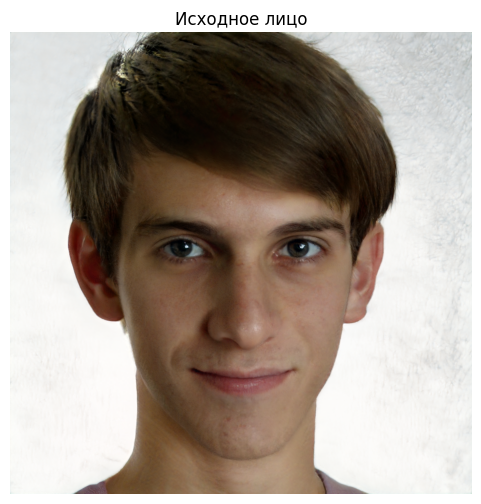

Форма initial_w: torch.Size([1, 18, 512])


In [34]:
# Генерируем одно лицо для теста
z = torch.randn([1, 512]).to(device)
initial_w = gan.mapping(z, None)

def display_image_tensor(img_tensor, title=""):
    img = (img_tensor[0].permute(1, 2, 0) * 127.5 + 128).clamp(0, 255).to(torch.uint8)
    plt.figure(figsize=(6, 6))
    plt.imshow(img.cpu().numpy())
    plt.title(title)
    plt.axis('off')
    plt.show()

# Показываем исходное лицо
with torch.no_grad():
    initial_img = gan.synthesis(initial_w, noise_mode='const')
display_image_tensor(initial_img, "Исходное лицо")
print(f"Форма initial_w: {initial_w.shape}")

# Сохраняем латентный код для использования
test_w = initial_w

Некоторые варианты промптов:

- prompt = "a person with beard"  
- prompt = "old person", "smiling person"
- prompt = "a person with glasses"


In [87]:
prompt = "smiling person"
edited_w, edited_img, losses, orig_img = optimizer.optimize(
    initial_w=test_w,
    text_prompt=prompt,
    num_iter=180,
    lr=0.12
)

Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... 

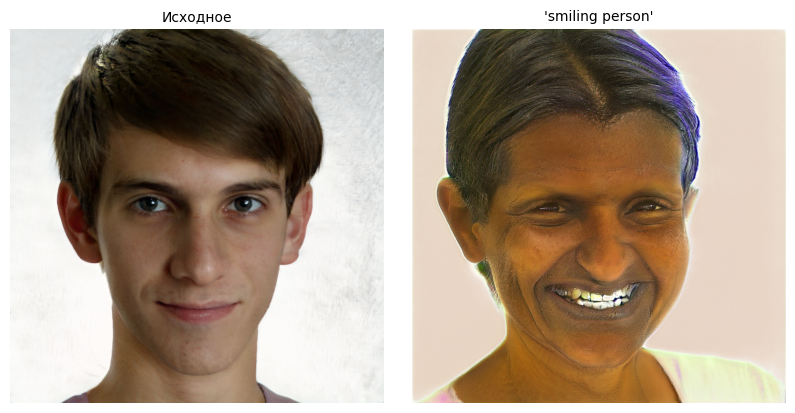

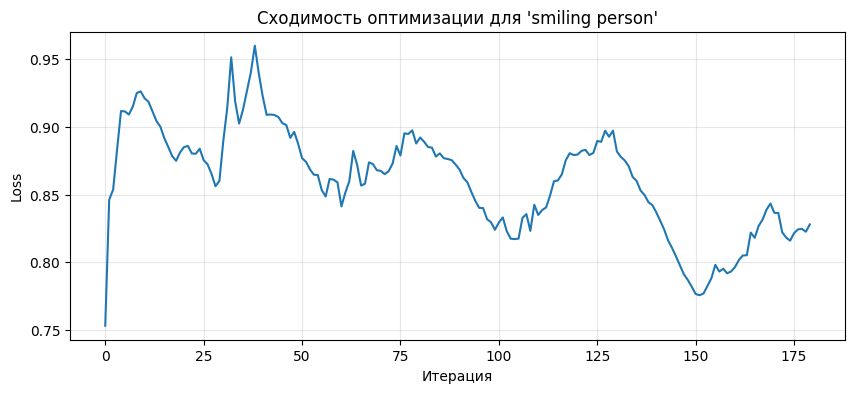

In [90]:
show_small_grid(
    images=[orig_img, edited_img],
    titles=["Исходное", f"'{prompt}'"],
    cols=2,
    img_scale=0.8
)

# График потерь
plt.figure(figsize=(10, 4))
plt.plot(losses)
plt.xlabel("Итерация")
plt.ylabel("Loss")
plt.title(f"Сходимость оптимизации для '{prompt}'")
plt.grid(True, alpha=0.3)
plt.show()

Красавчик, однако! А главное - улыбается во все 32!!!!

**Вывод:**

При редактировании по промпту 'smiling person' метод порождает артефакты, теряя исходную идентичность.

Это говорит о необходимости более сильной регуляризации при редактировании тонких атрибутов.


In [91]:
def optimize_balanced(self, initial_w, text_prompt, num_iter=100, lr=0.08):
    w = initial_w.clone().detach().requires_grad_(True)
    text_features = self.encode_text(text_prompt)

    with torch.no_grad():
        init_img = self.gan.synthesis(initial_w, noise_mode='const')

    optimizer = torch.optim.Adam([w], lr=lr)
    losses = []

    print(f'Оптимизация: "{text_prompt}"')
    for i in range(num_iter):
        optimizer.zero_grad()
        img = self.gan.synthesis(w, noise_mode='const')

        l_clip = self.clip_loss(img, text_features) * 0.5
        l_id = self.identity_loss(init_img, img) * 0.3
        l_reg = torch.norm(w - initial_w) * 0.01

        total_loss = l_clip + l_id + l_reg
        total_loss.backward()
        optimizer.step()

        losses.append(total_loss.item())

        if i % 20 == 0:
            print(f'  Итерация {i:3d}, Loss: {total_loss.item():.4f}')

    with torch.no_grad():
        final_img = self.gan.synthesis(w, noise_mode='const')

    print(f'Готово')
    return w, final_img, losses, init_img

# Добавляем метод в оптимизатор
optimizer.optimize_balanced = optimize_balanced.__get__(optimizer, StyleCLIPOptimizer)

In [92]:
prompt = "smiling person"
edited_w, edited_img, losses, orig_img = optimizer.optimize_balanced(
    initial_w=test_w,
    text_prompt=prompt,
    num_iter=100,
    lr=0.08
)

Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Оптимизация: "smiling person"
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch

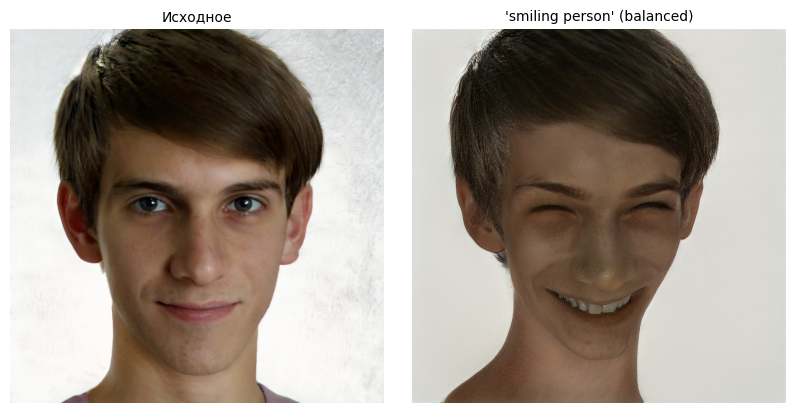

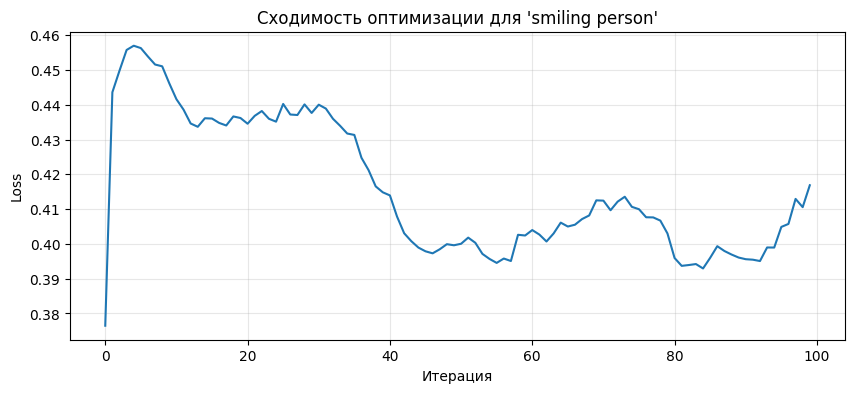

In [94]:
show_small_grid(
    images=[orig_img, edited_img],
    titles=["Исходное", f"'{prompt}' (balanced)"],
    cols=2,
    img_scale=0.8
)

# График потерь
plt.figure(figsize=(10, 4))
plt.plot(losses)
plt.xlabel("Итерация")
plt.ylabel("Loss")
plt.title(f"Сходимость оптимизации для '{prompt}'")
plt.grid(True, alpha=0.3)
plt.show()

**Ух ты ж...**

Половина лица очень даже похожf, улыбка есть, но вот остальное.....

In [95]:
def optimize_subtle(self, initial_w, text_prompt, num_iter=80, lr=0.07):
    w = initial_w.clone().detach().requires_grad_(True)
    text_features = self.encode_text(text_prompt)

    with torch.no_grad():
        init_img = self.gan.synthesis(initial_w, noise_mode='const')

    optimizer = torch.optim.Adam([w], lr=lr)
    losses = []

    print(f'Оптимизация: "{text_prompt}"')
    for i in range(num_iter):
        optimizer.zero_grad()
        img = self.gan.synthesis(w, noise_mode='const')

        l_clip = self.clip_loss(img, text_features) * 0.4
        l_id = self.identity_loss(init_img, img) * 0.7
        l_reg = torch.norm(w - initial_w) * 0.02

        total_loss = l_clip + l_id + l_reg
        total_loss.backward()
        optimizer.step()

        losses.append(total_loss.item())

        if i % 20 == 0:
            print(f'Итерация {i:3d}, Loss: {total_loss.item():.4f}')

    with torch.no_grad():
        final_img = self.gan.synthesis(w, noise_mode='const')

    print(f'Готово')
    return w, final_img, losses, init_img

optimizer.optimize_subtle = optimize_subtle.__get__(optimizer, StyleCLIPOptimizer)

In [96]:
prompts_to_try = [
    "slightly smiling person",
    "person with a subtle smile",
    "person with a gentle smile"
]

all_images = []
all_titles = []
all_losses = []
all_prompts = []

for prompt in prompts_to_try:
    print(f"Оптимизация: '{prompt}'")
    edited_w, edited_img, losses, orig_img = optimizer.optimize_subtle(
        initial_w=test_w,
        text_prompt=prompt,
        num_iter=80,
        lr=0.07
    )

    all_images.append(orig_img)
    all_images.append(edited_img)
    all_titles.append("Исходник")
    all_titles.append(f"'{prompt[:10]}...'")

    all_losses.append(losses)
    all_prompts.append(prompt)

Оптимизация: 'slightly smiling person'
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Оптимизация: "slightly smiling person"
Setting up PyTorch plugin 

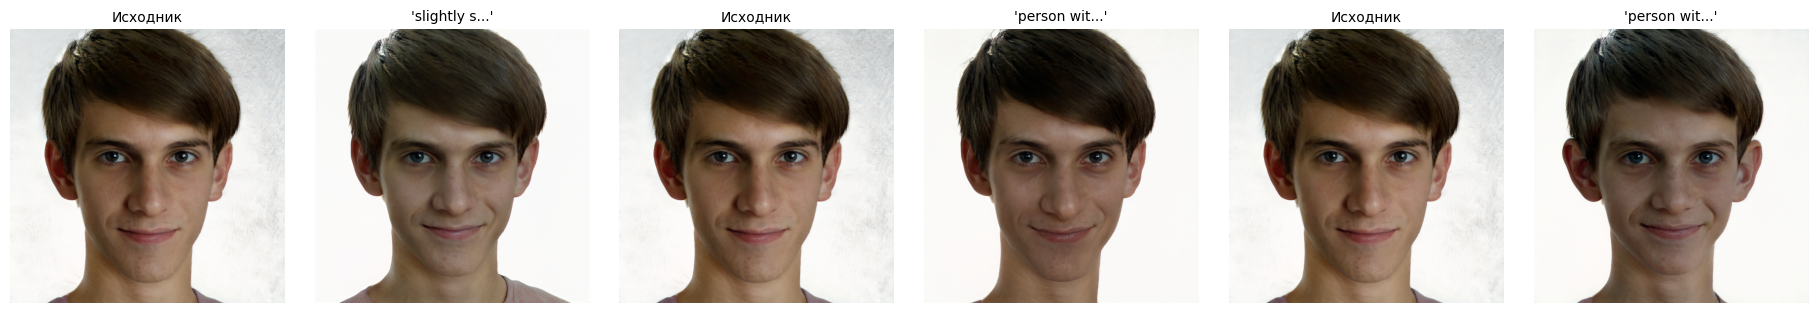

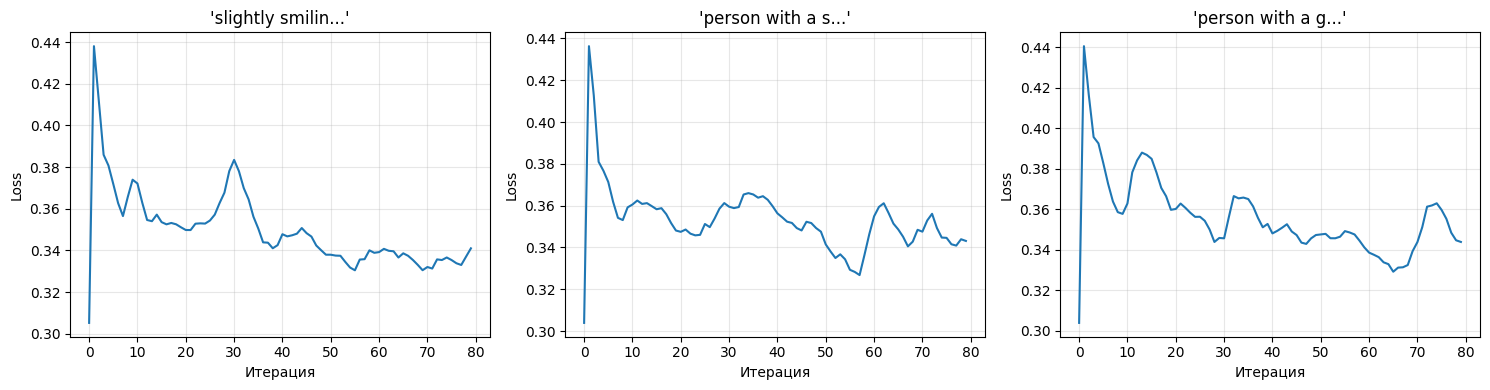

In [97]:
show_small_grid(
    images=all_images,
    titles=all_titles,
    cols=6,
    img_scale=0.6
)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for idx, (losses, prompt) in enumerate(zip(all_losses, all_prompts)):
    axes[idx].plot(losses)
    axes[idx].set_xlabel("Итерация")
    axes[idx].set_ylabel("Loss")
    axes[idx].set_title(f"'{prompt[:15]}...'")
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**Вывод:**

**А вот тут мы уже видим неплохие изображения.**

Да, последний вариант стал младше, но прослеживаются общие черты, одинаковая форма лица, цвет волос.

Мы изначально брали комфортный для человеческого глаза вариант улыбки:

-    "slightly smiling person",      
-    "person with a subtle smile",   
-    "person with a gentle smile"  


**Результат есть:**
- Носогубные складки напрягаются по-зазному
- Изменения слабые, потому что промпты "subtle", "gentle", "slightly"
- Личность сохраняется, лицо почти не превратилось в другого человека
- Оскал на лицах не наблюдаеься

Еще один эксперимент ради разнообразия.

In [98]:
def optimize_focus(self, initial_w, text_prompt, num_iter=200, lr=0.15):
    """Оптимизация с фокусом на CLIP, но с защитой от артефактов."""
    w = initial_w.clone().detach().requires_grad_(True)
    text_features = self.encode_text(text_prompt)

    optimizer = torch.optim.Adam([w], lr=lr)
    losses = []
    similarities = []

    for i in range(num_iter):
        optimizer.zero_grad()
        img = self.gan.synthesis(w, noise_mode='const')

        l_clip = self.clip_loss(img, text_features) * 2.5
        l_reg = torch.norm(w - initial_w) * 0.01

        total_loss = l_clip + l_reg
        total_loss.backward()
        optimizer.step()

        losses.append(total_loss.item())

        if i % 40 == 0:
            with torch.no_grad():
                current_features = self.encode_image(img)
                similarity = torch.cosine_similarity(text_features, current_features).item()
                similarities.append(similarity)
            print(f'  Итерация {i:3d}, Loss: {total_loss.item():.4f}, Сходство: {similarity:.3f}')

    with torch.no_grad():
        final_img = self.gan.synthesis(w, noise_mode='const')
        final_features = self.encode_image(final_img)
        final_similarity = torch.cosine_similarity(text_features, final_features).item()

    print(f'Готово. Финальное сходство: {final_similarity:.3f}')
    return w, final_img, losses, similarities

optimizer.optimize_focus = optimize_focus.__get__(optimizer, StyleCLIPOptimizer)



In [70]:
prompt = "a woman"
edited_w_focus, edited_img_focus, losses_focus, sim_history = optimizer.optimize_focus(
    initial_w=test_w,
    text_prompt=prompt,
    num_iter=200,
    lr=0.15
)

Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
  Итерация   0, Loss: 2.0625, Сходство: 0.175
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Se

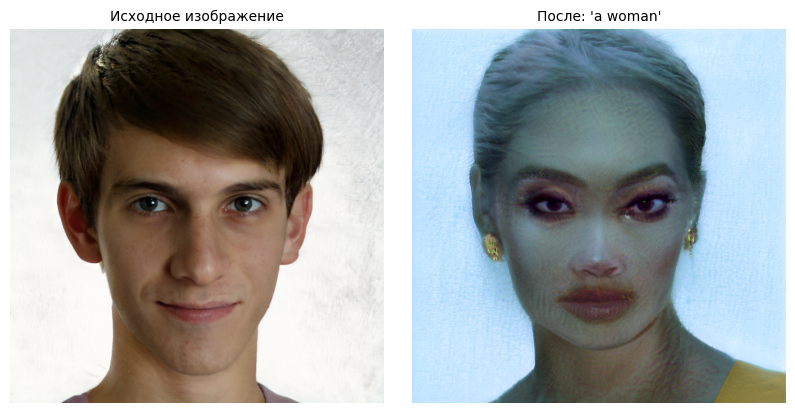

In [73]:
show_small_grid(
    images=[orig_img, edited_img_focus],
    titles=["Исходное изображение", f"После: '{prompt}'"],
    cols=2,
    img_scale=0.8
)


Получилась явная женщина, хоть и "нарисованная", и не похожая на исходного человека.

Это ожидаемый результат: когда мы сильно усиливаем CLIP loss и ослабляем identity loss, лицо радикально меняется в сторону промпта.

### **Выводы:**

1. **Метод StyleCLIP работает**: текстовые промпты действительно изменяют генерируемые изображения.

2. **Качество редактирования сильно зависит от баланса loss-функций**:
- Слишком сильный CLIP loss приводит к радикальным изменениям: **страшный другой человек**
- Слишком сильные identity loss и регуляризация подавляют изменения: **стал только загорелым**

3. **Разные атрибуты требуют разной силы редактирования**: балансирование между соответствием промпту и сохранением исходной идентичности

**Конечно, нет предела совершенству, но просто хотели познакомиться с архитетурой, которая похволяет использовать промпты для генерации и нам это удалось.**


### **P.S.**  Да и вообще - в сравнении с результатами GANов все ту просто принцы в детских сказках!!!!!